In [2]:
import pandas as pd
import anndata as ad
import os

from utils import *
from first_part import *
from matplotlib_venn import venn3, venn2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text
from gtfparse import read_gtf
import numpy as np
from sklearn.model_selection import train_test_split, GroupShuffleSplit 
import xgboost as xgb
from sklearn.model_selection import LeaveOneOut, RepeatedKFold, RepeatedStratifiedKFold, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mannwhitneyu, spearmanr, pearsonr
from statannotations import Annotator
import matplotlib
# from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from joblib import Parallel, delayed
from sklearn.feature_selection import VarianceThreshold 
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import balanced_accuracy_score
# from fgclustering import FgClustering
from sklearn.metrics import roc_curve, precision_recall_curve, auc

import seaborn as sns



In [18]:
atac_input_file_name = "/Users/eloiseberson/Documents/atac_pd/spor_gba1_lrrk2_bulk.csv"
peak_annot_path = "/Users/eloiseberson/Documents/atac_pd/_annot_chipseeker.tsv"
deconv_path = "../../Cellformer/cellformer_PD/adata_deconvolution_PD_2024_trained_all_filtered_Nov24.h5ad"
adata = prepareDataBulk(atac_input_file_name, deconv_path,peak_annot_path)
adata

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 153 × 141808
    obs: 'filename', 'Sample_num', 'brain_region', 'Group', 'PatientID', 'Neuritic plaque density binary', 'Braak score NFT binary', 'xxx.Braak score', 'xxx.Unified LB Stage', 'AD path', 'PD clinical', 'Neocortical LB', 'Brainstem/Limbic LB', 'ApoE_4', 'ApoE_2', 'Cognitive Imp', 'PD path', 'Sex', 'ApoE', 'age at death', 'group', 'MutationType', 'ADNC', 'CI', 'Braak Score', 'LB Stages', 'Total path'
    var: 'peakid', 'seqnames', 'start', 'end', 'width', 'strand', 'V4', 'annotation', 'geneChr', 'geneStart', 'geneEnd', 'geneLength', 'geneStrand', 'geneId', 'transcriptId', 'distanceToTSS', 'ENSEMBL', 'SYMBOL', 'GENENAME'

In [19]:
# 
adata.var.index = adata.var.index.astype(str)
adata.obs.index = adata.obs.index.astype(str)
adata =adata[adata.obs["group"].isin(["GBA1","SPOR"])]


# norma = "cpm"
# sc.pp.normalize_total(adata)
# sc.pp.log1p(adata)


n_peaks_to_keep = 131884
adata.var['peak_variance'] = adata.X.var(axis=0)
top_peaks = adata.var.sort_values('peak_variance', ascending=False).index[:int(n_peaks_to_keep)]
adata = adata[:, top_peaks]


/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_67446/3168804628.py:13: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['peak_variance'] = adata.X.var(axis=0)


In [20]:
def train_predict_evaluate_all(X, Y,group, num_iterations=50, test_size=0.5, num_boost_round=30):
    """
    Trains XGBoost models on the provided dataset, makes predictions, and evaluates the models using AUROC.
    
    Parameters:
    - X: Normalized feature matrix.
    - Y: Target variable array.
    - num_iterations: Number of training iterations/models to create.
    - test_size: Fraction of the dataset to be used as test set.
    - num_boost_round: Number of boosting rounds.
    
    Returns:
    - auroc
    """
    # Initialize an array to store predictions, filled with NaN
    ans = np.full((X.shape[0], num_iterations), np.nan)
    
    for i in tqdm(range(num_iterations)):
        # print(f'Iteration: {i}')
        # Split data
        # X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, stratify=Y, random_state=i, group=group)
        
        # Get test indices
        # indices_train, indices_test = train_test_split(range(X.shape[0]), test_size=test_size, stratify=Y, random_state=i, group=group)
        splitter = GroupShuffleSplit(test_size=test_size, n_splits=2, random_state = i)
        split = splitter.split(range(X.shape[0]), groups=group)
        indices_train, indices_test = next(split)
        X_train, y_train = X[indices_train], Y[indices_train]
        X_test, y_test = X[indices_test], Y[indices_test]
        # Prepare the data for XGBoost
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dtest = xgb.DMatrix(X_test)
        
        # Define model parameters
        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'use_label_encoder': False,
            'verbosity': 0
        }
        
        # Train the model
        model = xgb.train(params, dtrain, num_boost_round=num_boost_round)
        
        # Predict on the test set
        y_pred = model.predict(dtest)
        
        # Round the predictions to three decimal places
        y_pred_rounded = np.round(y_pred, 7)
        
        # Store the predictions
        for idx, pred in zip(indices_test, y_pred_rounded):
            ans[idx, i] = pred
    
    # Average the predictions across the iterations for each instance
    avg_predictions = np.nanmean(ans, axis=1)
    
    # # Calculate and return AUROC
    # auroc = roc_auc_score(Y, avg_predictions)
    # auprc = average_precision_score(Y, avg_predictions)
    return ans



In [14]:
dico_res = {}
comp = [("SPOR", "GBA1")]
## GBA1 versus SPOR
for v1,v2, in comp:
    for br in adata.obs.brain_region.unique():
        adata_pd_g = adata[(adata.obs.group.isin([v1, v2])) &( adata.obs.brain_region==br)]
        X = adata_pd_g.to_df().values
        
        person_id = adata_pd_g.obs.Sample_num.tolist()
        y = adata_pd_g.obs["group"].map({v1:0, v2:1}).values
        X.shape
        
        ans = train_predict_evaluate_all(X, y,person_id, num_iterations=100, test_size=0.3, num_boost_round=30)
        avg_predictions = np.nanmean(ans, axis=1)
        auroc = roc_auc_score(y, avg_predictions)
        auprc = average_precision_score(y, avg_predictions)
        print(f"{v1} versus {v2} results: {auroc}, {auprc}")
        dico_res["%s_%svs%s"%(br,v1,v2)] = (avg_predictions, y)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:36<00:00,  2.74it/s]


SPOR versus GBA1 results: 0.3956043956043956, 0.5013049987297479


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:33<00:00,  2.95it/s]


SPOR versus GBA1 results: 0.41666666666666663, 0.46883520547220237


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  6.99it/s]


...

SPOR versus GBA1 results: 0.20238095238095238, 0.40331004576223606


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:29<00:00,  3.42it/s]


SPOR versus GBA1 results: 0.5277777777777778, 0.5593782173945216


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:33<00:00,  3.02it/s]

SPOR versus GBA1 results: 0.543956043956044, 0.53305355635077


In [15]:
import pickle 

with open('atac_seq_bulk.pkl', 'wb') as f:
    pickle.dump(dico_res, f)

In [16]:
import pickle 

with open('atac_seq_bulk.pkl', 'rb') as f:
    dico_res = pickle.load( f)

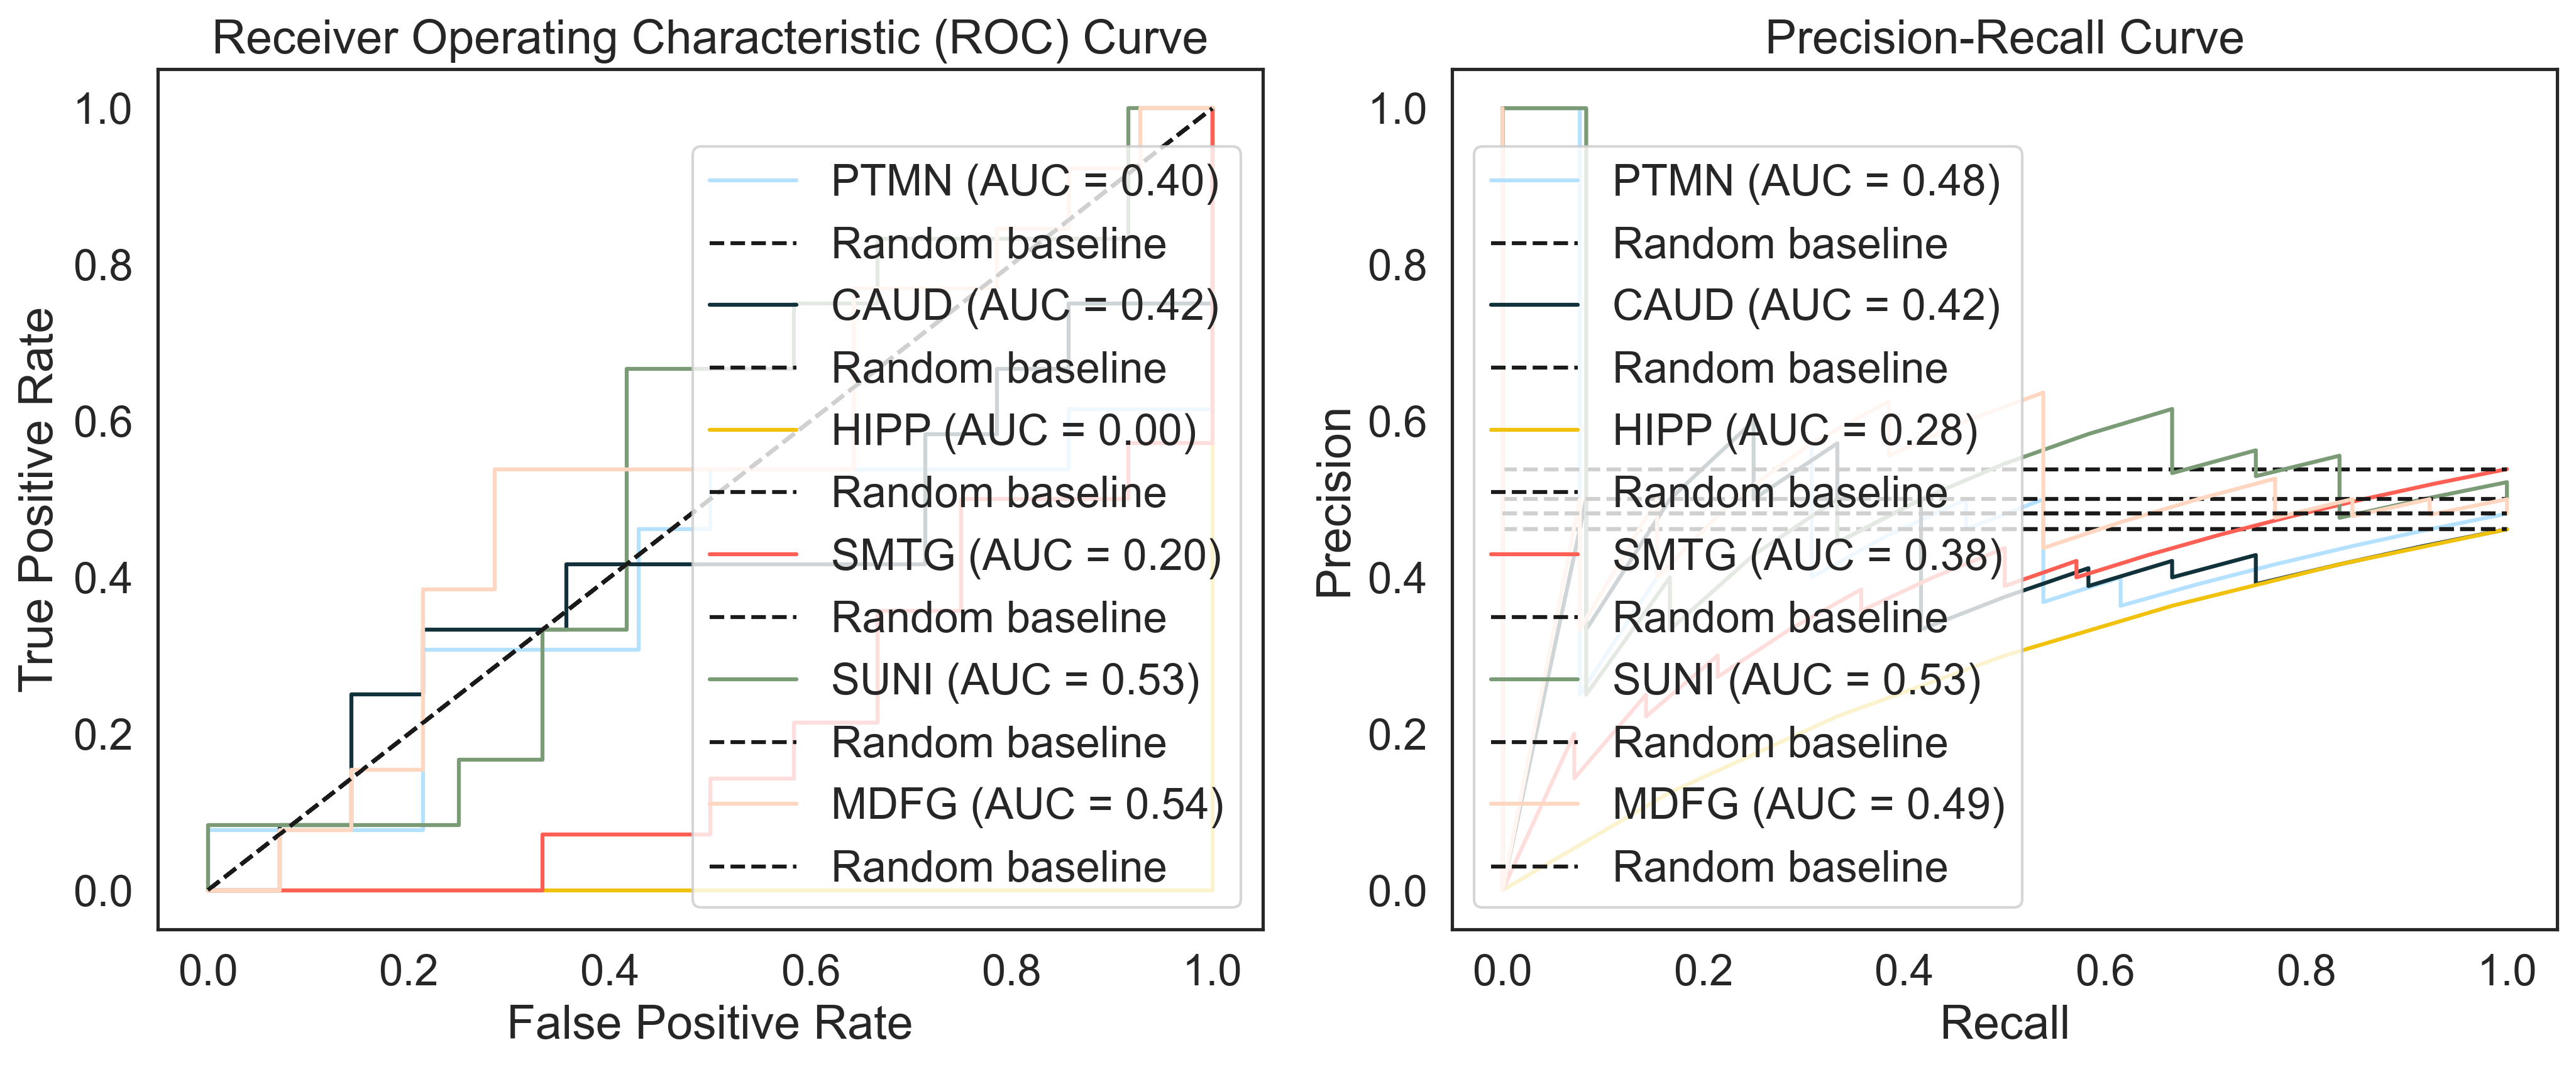

In [17]:

# Plot ROC Curve
plt.figure(figsize=(14, 6))

verse="LRRK2"
palette={"%svsGBA1"%verse:"#2D1E2F",  "SPORvs%s"%verse:"#AB4283","SPORvsGBA1":"#ababab"}
sns.set(style="white", font_scale=1.5)
for key, (av,yy) in dico_res.items():
    # ROC Curve
    fpr, tpr, roc_thresholds = roc_curve(yy, av)
    roc_auc = auc(fpr, tpr)
    br = key.split("_")[0]
    # Precision-Recall Curve
    precision, recall, prc_thresholds = precision_recall_curve(yy, av)
    prc_auc = auc(recall, precision)

    prevalence = len(np.asarray(yy)[np.asarray(yy)==1])/len(yy)

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f"{br} (AUC = {roc_auc:.2f})", color=COLORS_CT[br])
    plt.plot([0, 1], [0, 1], 'k--', label="Random baseline")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.grid()
    
    # Plot PRC Curve
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label=f"{br} (AUC = {prc_auc:.2f})", color=COLORS_CT[br])
    plt.plot([0, 1], [prevalence, prevalence], 'k--', label="Random baseline")
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="lower left")
    plt.grid()
    
    plt.tight_layout()

plt.savefig("./outdir/roc_prc_multivariate_bulk_atac_seq.svg")
plt.show()

In [ ]:
v1 = "SPOR"
v2 = "GBA1"
adata_pd.obs.reset_index(drop=True, inplace=True)
av, y = dico_res["%svs%s"%(v1,v2)]
df_res = pd.DataFrame(av, columns=["mean prediction"])
df_res["groundtruth"] = y
df_res["Model error"] = np.abs(av.astype(float)-y.astype(float))
adata_pd_g = adata_pd[adata_pd.obs.subgroup.isin([v1, v2])]

for it in adata_pd_g.obs.columns :
    df_res[it] = adata_pd_g.obs[it].tolist()


In [ ]:
df_res[df_res.subgroup=="GBA1"]

In [ ]:
df_res["Under dopaminergic medication"] = df_res['PDTRTMNT'].map({0:"No Treatment",1:"Treatment"})
COLORS_CT["No Treatment"] = "#ababab"
COLORS_CT["Treatment"] = COLORS_CT["Female"]

fig, ax = plt.subplots()
sns.boxplot(data=df_res, x="subgroup", y="mean prediction", hue="Under dopaminergic medication", 
            dodge=True, ax=ax, fill=False, color="k",showfliers=False)

sns.stripplot(data=df_res, x="subgroup", y="mean prediction", hue="Under dopaminergic medication", 
              dodge=True, ax=ax, palette=COLORS_CT)

pairs = [(("GBA1","Treatment"),("GBA1","No Treatment")),
          (("SPOR","Treatment"),("SPOR","No Treatment"))]
annotator= Annotator.Annotator(data=df_res, x="subgroup", y="mean prediction", 
                     hue="Under dopaminergic medication",
                     ax=ax, pairs=pairs)
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Holm-Bonferroni')
annotator.apply_and_annotate()
ax.legend(bbox_to_anchor=(1,1))
plt.savefig("outdir/bulk_blood_model_treatment_differences.svg")


In [ ]:
df_res["Sex"] =df_res["SEX"].map({0:"Female", 1:"Male"})
fig, ax = plt.subplots()
sns.boxplot(data=df_res, x="subgroup", y="mean prediction", hue="Sex", 
            dodge=True, ax=ax, fill=False, color="k", showfliers=False)

sns.stripplot(data=df_res, x="subgroup", y="mean prediction", 
              hue="Sex", dodge=True, palette=COLORS_CT)
pairs = [(("GBA1","Female"),("GBA1","Male")),
          (("SPOR","Female"),("SPOR","Male"))]
annotator= Annotator.Annotator(data=df_res, x="subgroup", y="mean prediction", 
                     hue="Sex",
                     ax=ax, pairs=pairs)
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Holm-Bonferroni')
annotator.apply_and_annotate()
ax.legend(bbox_to_anchor=(1,1))
plt.savefig("outdir/bulk_blood_model_sex_differences.svg")


In [ ]:
# df_res["Disease duration"] = df_res["fampd"].map({1:"1st Degree Family w/PD",
#                                                 2:"Non-1st Degree Family w/PD",
#                                                 3:"No Family w/PD"})

sns.stripplot(data=df_res[df_res.PDTRTMNT==1], x="subgroup", y="mean prediction", hue="duration_yrs",  dodge=True, palette=cmap)
ax.legend(bbox_to_anchor=(1,1))

In [ ]:
df_res["Family History"] = df_res["fampd"].map({1:"1st Degree Family w/PD",
                                                2:"Non-1st Degree Family w/PD",
                                                3:"No Family w/PD"})
COLORS_CT["No Family w/PD"] = "#45556B"
COLORS_CT["Non-1st Degree Family w/PD"] = "#809EC9"
COLORS_CT["1st Degree Family w/PD"] = "#96B9EB"
fig, ax = plt.subplots()
sns.boxplot(data=df_res, x="subgroup", y="mean prediction", 
            hue="Family History",  dodge=True, color="k", fill=False, ax=ax, showfliers=False)
sns.stripplot(data=df_res, x="subgroup", y="mean prediction",
              hue="Family History",  dodge=True,  ax=ax, palette=COLORS_CT)
pairs = [(("GBA1","No Family w/PD"),("GBA1","1st Degree Family w/PD")),
          (("SPOR","No Family w/PD"),("SPOR","1st Degree Family w/PD"))]
annotator= Annotator.Annotator(data=df_res, x="subgroup", y="mean prediction", 
                     hue="Family History",
                     ax=ax, pairs=pairs)
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Holm-Bonferroni')
annotator.apply_and_annotate()
ax.legend(bbox_to_anchor=(1,1))
plt.savefig("outdir/bulk_blood_model_fmiliy_history_differences.svg")


In [ ]:
# df_res["Family History"] = df_res["fampd"].map({1:"1st Degree Family w/PD",
#                                                 2:"Non-1st Degree Family w/PD",
#                                                 3:"No Family w/PD"})
# COLORS_CT["No Family w/PD"] = "#45556B"
# COLORS_CT["Non-1st Degree Family w/PD"] = "#809EC9"
# COLORS_CT["1st Degree Family w/PD"] = "#96B9EB"
fig, ax = plt.subplots()
sns.boxplot(data=df_res, x="subgroup", y="mean prediction", 
            hue="EDUCYRS",  dodge=True, color="k", fill=False, ax=ax, showfliers=False)
sns.stripplot(data=df_res, x="subgroup", y="mean prediction",
              hue="EDUCYRS",  dodge=True,  ax=ax)#, palette=COLORS_CT)
# pairs = [(("GBA1","No Family w/PD"),("GBA1","1st Degree Family w/PD")),
#           (("SPOR","No Family w/PD"),("SPOR","1st Degree Family w/PD"))]
# annotator= Annotator.Annotator(data=df_res, x="subgroup", y="mean prediction", 
#                      hue="Family History",
#                      ax=ax, pairs=pairs)
# annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Holm-Bonferroni')
# annotator.apply_and_annotate()
ax.legend(bbox_to_anchor=(1,1))

In [ ]:
ax = sns.stripplot(data=df_res, x="subgroup", y="mean prediction", hue="GBA_mutation",  dodge=True)
ax.legend(bbox_to_anchor=(1,1))

-0.17631183864879535 1.2020193074497185e-06


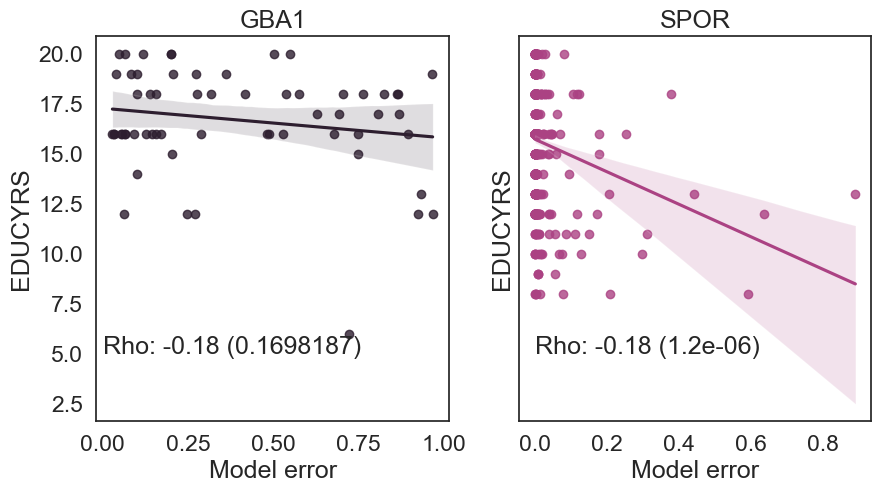

In [46]:
var="EDUCYRS"
meth = pearsonr
fig, axes = plt.subplots(1,2,figsize=(10,5),sharey=True)
tmp1 =df_res[df_res.subgroup=="GBA1"]
tmp1 = tmp1[~tmp1[var].isna()]
sns.regplot(data=tmp1, x="Model error", y=var, 
            color=COLORS_CT["GBA1"], 
           ax=axes[0],)
            #hue="Under dopaminergic medication")
tmp2 =df_res[df_res.subgroup=="SPOR"]
tmp2 = tmp2[~tmp2[var].isna()]
sns.regplot(data=tmp2, x="Model error", y=var,#hue="Under dopaminergic medication",
            color=COLORS_CT["SPOR"], 
           ax=axes[1])

axes[0].set_title("GBA1")
axes[1].set_title("SPOR")

sp , p = meth(tmp1["Model error"], tmp1[var])
axes[0].text(0,5, "Rho: %s (%s)"%(str(np.round(sp,2)),str(np.round(p,7))))


sp , p = meth(tmp2["Model error"], tmp2[var])
axes[1].text(0,5, "Rho: %s (%s)"%(str(np.round(sp,2)),str(np.round(p,7))))
print(sp, p)

plt.savefig("outdir/bulk_blood_model_%s_differences.svg"%var)

# sns.regplot(data=df_res, x="error", y="duration",color="grey", ax=ax)

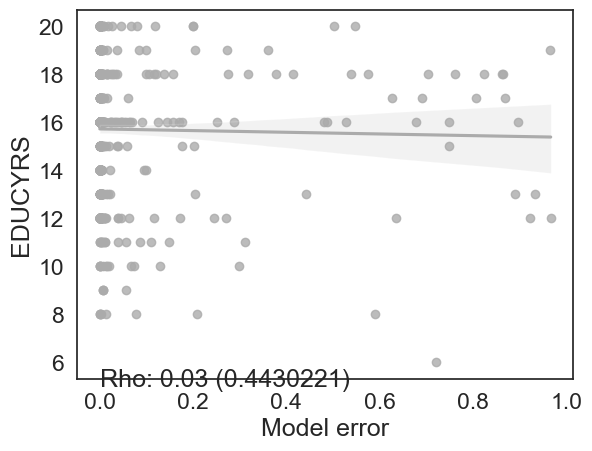

In [49]:
var="EDUCYRS"
meth = spearmanr
fig, ax = plt.subplots()
tmp = df_res[~df_res[var].isna()]
# tmp = tmp[tmp.subgroup=="GBA1"]
sns.regplot(data=tmp, x="Model error", y=var,
            color="#ababab", ax=ax)


sp , p = meth(tmp["Model error"], tmp[var])
ax.text(0,5, "Rho: %s (%s)"%(str(np.round(sp,2)),str(np.round(p,7))))


plt.savefig("outdir/bulk_blood_model_%s_differences_combined.svg"%var)

In [53]:


adata_pd_g.obs.columns.tolist()
root="/Volumes/U32 Shadow/data/ATAC-seq/PPMI/Subject_Demographics/"
dico_feat = pd.read_excel(os.path.join(root, "PPMI_Curated_Data_Cut_Public_20240729.xlsx"), 
                          sheet_name="Data dictionary")[["Variable", "Category", "Description"]].drop_duplicates()
dico_feat = dico_feat[~dico_feat.Category.isna()]
dico_feat

,Variable,Category,Description
0,SITE,ID,Blinded Site ID
1,PATNO,ID,Participant ID
2,COHORT,ID,Cohort at Enrollment
6,subgroup,ID,List of Subgroup(s) based on enrollment cohort...
7,study_status,ID,PPMI study status
...,...,...,...
366,Stage_Subpark,NSD-ISS,Subthreshold Parkinsonism score - modified MDS...
367,Stage_PDTreat,NSD-ISS,Indicates PD treatment status at visit based o...
369,Stage_S,NSD-ISS,Subject-level a-syn SAA status (Note: Results ...
373,Stage_D,NSD-ISS,Visit-level DAT SBR status - indicates whether...


In [54]:
df_res[df_res.group==group][["Model error"]+cols]

NameError: name 'group' is not defined

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/1444705557.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  p,_ = pearsonr(x,y)
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/1444705557.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _, pval = pearsonr(x,y)
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/1444705557.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


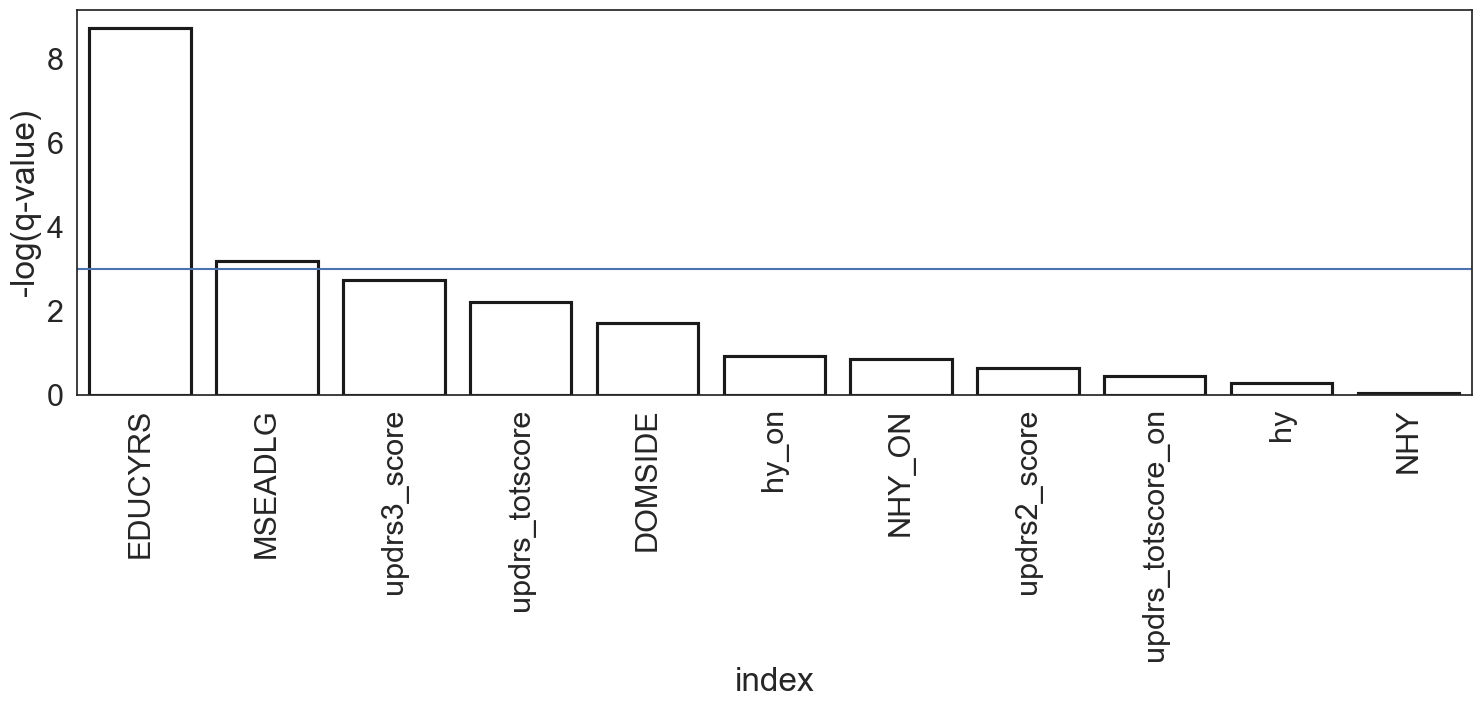

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/1444705557.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


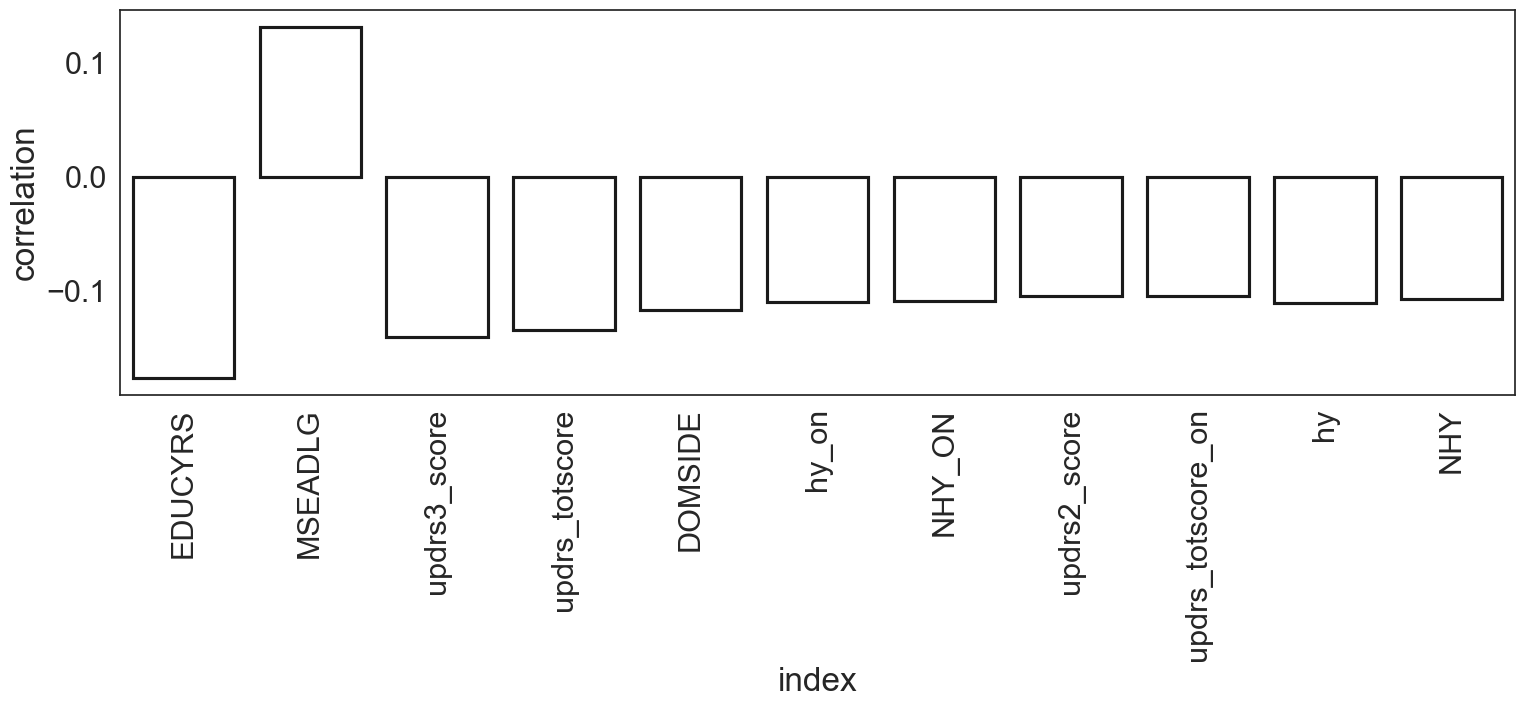

In [55]:
from statsmodels.stats.multitest import multipletests 
meth = pearsonr
def getmeth(x, y):
    # print(x.shape)
    p,_ = pearsonr(x,y)
    return p

def getpvalue(x, y):
    # print(x.shape)
    _, pval = pearsonr(x,y)
    return pval

cols = dico_feat[dico_feat.Category !="ID"].Variable.unique().tolist()
cols = [it for it in cols if it in df_res.columns.tolist()]
toremove = ['APOE', "NSD_STAGE", "Stage_G", "clockdraw", 
            "lexical", "MODBNT", "OTHNEURO", "TMT_A", "TMT_B",
            "howlive", "sex_orient", "updrs4_score"]

cols = [it for it in cols if it not in toremove]
group = "SPOR"
mat = df_res[df_res.group==group][["Model error"]+cols].corr(method=getmeth)
mat = mat.iloc[0, 1:].reset_index()
mat.columns = ["index", "correlation"]
pval = df_res[df_res.group==group][["Model error"]+cols].corr(method=getpvalue)
pval = pval.iloc[0, 1:].reset_index()
pval.columns = ["index", "pval"]
mat = mat.merge(pval, on="index")
_, qval, _, _ = multipletests(mat["pval"].values, method="holm")
mat["qval"] = qval

mat["-log(q-value)"] = -np.log(mat["qval"])
mat

mat = mat.sort_values("-log(q-value)", ascending=False)
sns.set(style="white", font_scale=2)
fig, ax = plt.subplots(figsize=(18,5))
sns.barplot(data=mat[mat.qval<1], x="index", y="-log(q-value)", ax=ax, color="k", fill=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.axhline(y=-np.log(0.05))
plt.show()
fig, ax = plt.subplots(figsize=(18,5))
sns.barplot(data=mat[mat.qval<1], x="index", y="correlation", ax=ax, color="k", fill=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/1444705557.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  p,_ = pearsonr(x,y)
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/2629150738.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _, pval = pearsonr(x,y)
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/2629150738.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


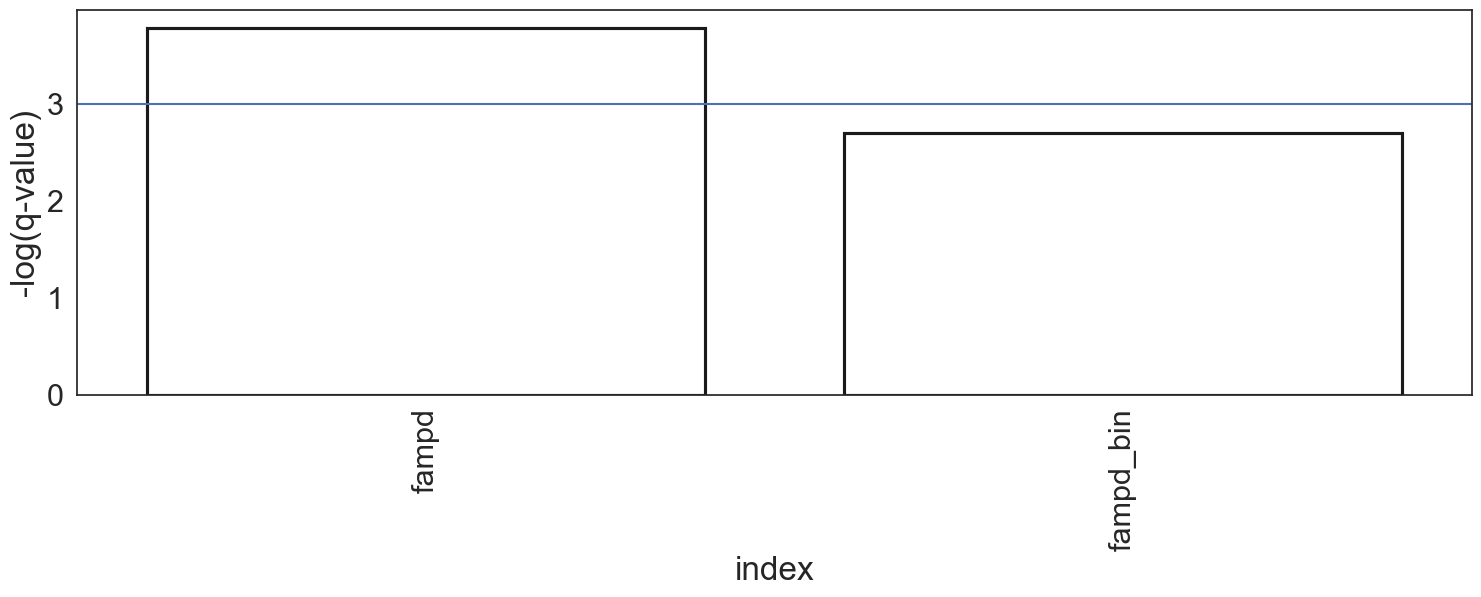

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/2629150738.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


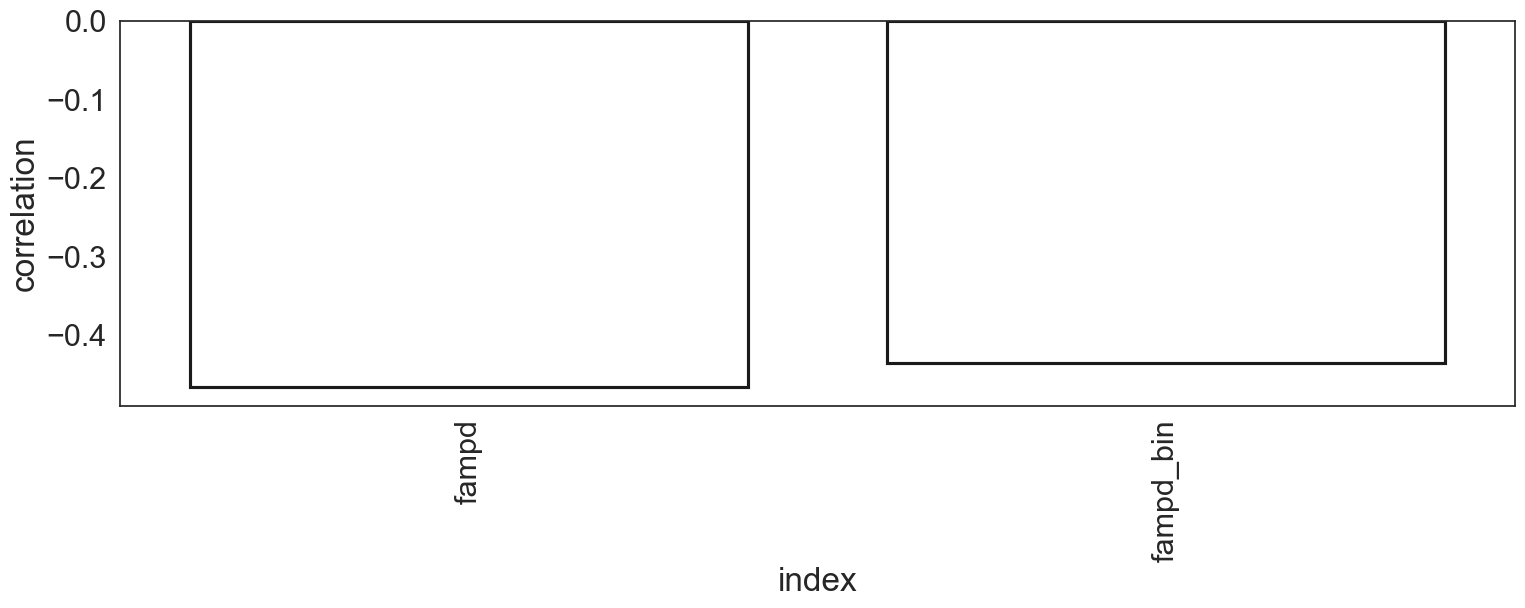

In [56]:
from statsmodels.stats.multitest import multipletests 

def getpvalue(x, y):
    # print(x.shape)
    _, pval = pearsonr(x,y)
    return pval

cols = dico_feat[dico_feat.Category !="ID"].Variable.unique().tolist()
cols = [it for it in cols if it in df_res.columns.tolist()]
toremove = ['APOE', "NSD_STAGE", "Stage_G", "clockdraw", 
            "lexical", "MODBNT", "OTHNEURO", "TMT_A", "TMT_B",
            "howlive", "sex_orient", "updrs4_score"]

cols = [it for it in cols if it not in toremove]
group = "GBA1"
mat = df_res[df_res.group==group][["Model error"]+cols].corr(method=getmeth)
mat = mat.iloc[0, 1:].reset_index()
mat.columns = ["index", "correlation"]
pval = df_res[df_res.group==group][["Model error"]+cols].corr(method=getpvalue)
pval = pval.iloc[0, 1:].reset_index()
pval.columns = ["index", "pval"]
mat = mat.merge(pval, on="index")
_, qval, _, _ = multipletests(mat["pval"].values, method="holm")
mat["qval"] = qval

mat["-log(q-value)"] = -np.log(mat["qval"])
mat

mat = mat.sort_values("-log(q-value)", ascending=False)
sns.set(style="white", font_scale=2)
fig, ax = plt.subplots(figsize=(18,5))
sns.barplot(data=mat[mat.qval<1], x="index", y="-log(q-value)", ax=ax, color="k", fill=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.axhline(y=-np.log(0.05))
plt.show()
fig, ax = plt.subplots(figsize=(18,5))
sns.barplot(data=mat[mat.qval<1], x="index", y="correlation", ax=ax, color="k", fill=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()